In [2]:
# 1. IMPORT LIBRARIES

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# 2. LOAD DATA

urbanev_master = pd.read_csv(
    "urbanev_master.csv"
)

tariff_recommendations = pd.read_csv(
    "tariff_recommendations.csv"
)

urbanev_master['timestamp'] = pd.to_datetime(
    urbanev_master['timestamp']
)

print(urbanev_master.shape)
print(tariff_recommendations.shape)

(2134080, 19)
(2134080, 5)


In [7]:
# 3. FIX TIMESTAMP TYPES

urbanev_master['timestamp'] = pd.to_datetime(
    urbanev_master['timestamp']
)

tariff_recommendations['timestamp'] = pd.to_datetime(
    tariff_recommendations['timestamp']
)

print(urbanev_master['timestamp'].dtype)
print(tariff_recommendations['timestamp'].dtype)

datetime64[ns]
datetime64[ns]


In [8]:
# 4. MERGE DATA

monitor_df = pd.merge(
    urbanev_master,
    tariff_recommendations,
    on=['timestamp','station_id'],
    how='left'
)

print(monitor_df.shape)

display(
    monitor_df.head()
)

(2134080, 22)


,timestamp,station_id,volume,occupancy,duration,energy_cost_per_kwh,num,count,fast_count,slow_count,...,la,CBD,dynamic_pricing,utilization_rate,revenue,occupancy_density,queue_proxy,demand_score,tariff_category,tariff_multiplier
0,2022-06-19 00:00:00,102,2.858333,12,0.49,0.924,1,30,3,27,...,22.54041,0,0,0.4,2.6411,0.4,1.143333,0.260260,Base,1.0
1,2022-06-19 00:05:00,102,4.375000,12,0.75,0.924,1,30,3,27,...,22.54041,0,0,0.4,4.0425,0.4,1.750000,0.260398,Base,1.0
2,2022-06-19 00:10:00,102,4.375000,12,0.75,0.924,1,30,3,27,...,22.54041,0,0,0.4,4.0425,0.4,1.750000,0.260398,Base,1.0
3,2022-06-19 00:15:00,102,4.375000,12,0.75,0.924,1,30,3,27,...,22.54041,0,0,0.4,4.0425,0.4,1.750000,0.260398,Base,1.0
4,2022-06-19 00:20:00,102,4.375000,12,0.75,0.924,1,30,3,27,...,22.54041,0,0,0.4,4.0425,0.4,1.750000,0.260398,Base,1.0


In [9]:
# 5. UTILIZATION ALERT

monitor_df['utilization_alert'] = np.where(
    monitor_df['utilization_rate'] > 0.70,
    'High Utilization',
    'Normal'
)

In [10]:
# 6. CONGESTION ALERT

monitor_df['congestion_alert'] = np.where(
    monitor_df['demand_score'] > 0.75,
    'Congestion Risk',
    'Normal'
)

In [11]:
# 7. PRICING ALERT

monitor_df['pricing_alert'] = np.where(
    monitor_df['tariff_category'] == 'Peak Premium',
    'Peak Pricing Required',
    'Normal'
)

In [12]:
# 8. ALERT SEVERITY

def alert_level(row):

    score = 0

    if row['utilization_rate'] > 0.70:
        score += 1

    if row['demand_score'] > 0.75:
        score += 1

    if row['tariff_category'] == 'Peak Premium':
        score += 1

    if score == 0:
        return 'Low'

    elif score == 1:
        return 'Medium'

    elif score == 2:
        return 'High'

    else:
        return 'Critical'


monitor_df['alert_level'] = monitor_df.apply(
    alert_level,
    axis=1
)

In [13]:
# ALERT SUMMARY

alert_summary = (
    monitor_df['alert_level']
    .value_counts()
    .reset_index()
)

alert_summary.columns = [
    'Alert Level',
    'Count'
]

display(alert_summary)

,Alert Level,Count
0,Low,2082188
1,Medium,51324
2,Critical,568


In [15]:
# 10. NETWORK HEALTH REPORT

network_summary = pd.DataFrame({

    'Metric':[

        'Average Utilization',

        'Average Occupancy Density',

        'Average Demand Score',

        'Critical Alerts'

    ],

    'Value':[

        monitor_df[
            'utilization_rate'
        ].mean(),

        monitor_df[
            'occupancy_density'
        ].mean(),

        monitor_df[
            'demand_score'
        ].mean(),

        (
            monitor_df[
                'alert_level'
            ]
            ==
            'Critical'
        ).sum()

    ]
})

display(network_summary)

,Metric,Value
0,Average Utilization,0.280248
1,Average Occupancy Density,0.280248
2,Average Demand Score,0.185963
3,Critical Alerts,568.000000


In [17]:
# 11. STATION HEALTH REPORT

station_health = (

    monitor_df

    .groupby('station_id')

    .agg({

        'utilization_rate':'mean',

        'occupancy_density':'mean',

        'demand_score':'mean'

    })

    .reset_index()

)

station_health = (

    station_health

    .sort_values(
        'demand_score',
        ascending=False
    )

)

display(
    station_health.head(20)
)

,station_id,utilization_rate,occupancy_density,demand_score
178,1029,0.760269,0.760269,0.506730
104,715,0.734580,0.734580,0.484424
227,1131,0.582488,0.582488,0.469652
59,570,0.639760,0.639760,0.417291
77,633,0.541361,0.541361,0.409562
110,732,0.614578,0.614578,0.406099
69,595,0.453683,0.453683,0.388777
164,982,0.589400,0.589400,0.383891
106,719,0.579707,0.579707,0.377149
103,712,0.575697,0.575697,0.376837


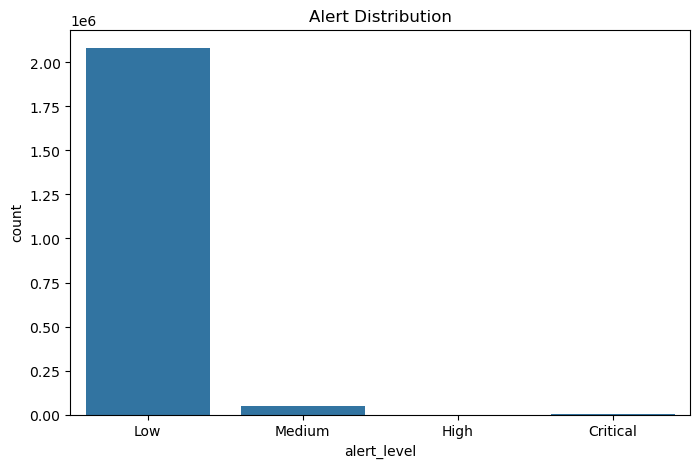

In [18]:
# 12. ALERT DISTRIBUTION

plt.figure(figsize=(8,5))

sns.countplot(
    x='alert_level',
    data=monitor_df,
    order=[
        'Low',
        'Medium',
        'High',
        'Critical'
    ]
)

plt.title(
    'Alert Distribution'
)

plt.show()

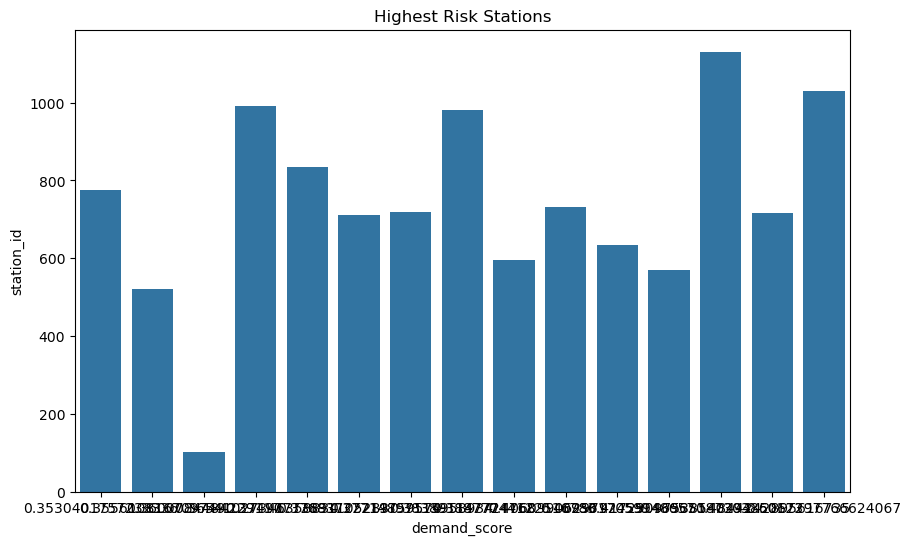

In [19]:
# 13. TOP RISK STATIONS

top_risk = station_health.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_risk,
    x='demand_score',
    y='station_id'
)

plt.title(
    'Highest Risk Stations'
)

plt.show()

In [20]:
# 14. EXPORT OUTPUTS

monitor_df.to_csv(
    "monitoring_alerts.csv",
    index=False
)

station_health.to_csv(
    "station_health_report.csv",
    index=False
)

network_summary.to_csv(
    "network_summary.csv",
    index=False
)

print(
    "All monitoring outputs exported successfully."
)

All monitoring outputs exported successfully.


In [21]:
# 15. MONITORING SUMMARY

print("="*50)
print("MONITORING AGENT RESULTS")
print("="*50)

print(
    f"Total Records : {len(monitor_df):,}"
)

print(
    f"Critical Alerts : {(monitor_df['alert_level']=='Critical').sum():,}"
)

print(
    f"Average Demand Score : {monitor_df['demand_score'].mean():.3f}"
)

print(
    f"Average Utilization : {monitor_df['utilization_rate'].mean():.3f}"
)

print("="*50)

MONITORING AGENT RESULTS
Total Records : 2,134,080
Critical Alerts : 568
Average Demand Score : 0.186
Average Utilization : 0.280
